# Astronomy Supervised

This example demonstrates a supervised astronomy workflow for classifying astronomical transients
from their multi-band light curves.

<div class="admonition note">
<p class="admonition-title">Note</p>
<p>This notebook is intentionally slightly more involved than the <a href="getting_started.html">Hello World</a>
and <a href="unsupervised_image_extragalactic.html">Astronomy Unsupervised</a> examples. Hyrax ships with
image-based models and datasets, but it is designed to work with <b>any</b> kind of data.
To demonstrate this, we define a <b>custom dataset class</b> and a <b>custom model</b> for
1-D light-curve data. If you are new to Hyrax, we recommend working through those earlier
examples first.</p>
</div>

## Overview

The workflow is:

- Download the PLAsTiCC light-curve dataset from the Multi-Modal Universe project
- Preprocess the variable-length light curves into fixed-size arrays
- Define a custom Hyrax dataset and a custom 1-D CNN model
- Train the classifier
- Predict transient classes on held-out test data
- Evaluate performance with a confusion matrix

## The data

This example uses the [PLAsTiCC](https://plasticc.org/) training set as reformatted by the
[Multi-Modal Universe](https://github.com/MultimodalUniverse/MultimodalUniverse) (MMU) project.
It contains roughly 7,800 labeled light curves across 14 classes of astronomical transients
and variables — including SNIa, SNII, SNIbc, TDE, AGN, RR Lyrae, kilonova, and more.
Each light curve has multi-band photometry (LSST *ugrizY*) with irregular cadence.

## The model

We define a lightweight 1-D convolutional neural network that treats each photometric band as
a channel. This is analogous to treating an RGB image as a 3-channel 2-D input, except here
each band is a 1-D time series.

## Install dependencies

We need Hyrax and the HuggingFace `datasets` library to download the MMU data.
You can skip this step if these are already installed in your environment.

In [ ]:
%pip install datasets

## Download the PLAsTiCC dataset

We load the PLAsTiCC training set directly from the MMU HuggingFace repository.
The download is roughly 15 MB.

In [2]:
from datasets import load_dataset

ds = load_dataset("MultimodalUniverse/plasticc", split="train")

print(f"Loaded {len(ds)} samples")
print(f"\nFeatures: {list(ds.features.keys())}")
print(f"\nFirst sample keys: {list(ds[0].keys())}")
print(f"Light curve keys:  {list(ds[0]['lightcurve'].keys())}")

Loaded 7848 samples

Features: ['lightcurve', 'hostgal_photoz', 'hostgal_specz', 'redshift', 'obj_type', 'object_id']

First sample keys: ['lightcurve', 'hostgal_photoz', 'hostgal_specz', 'redshift', 'obj_type', 'object_id']
Light curve keys:  ['band', 'flux', 'flux_err', 'time']


## Preprocess light curves

The raw light curves have variable lengths and irregular cadence across six LSST bands.
To feed them into a CNN we need a fixed-size representation.

For each object we:
1. Normalize observation times to \[0, 1\]
2. Bin the flux into 50 equally-spaced time bins per band
3. Average the flux in each occupied bin (empty bins stay at zero)
4. Normalize the resulting array per object

This produces a `(6, 50)` array per object — six channels, fifty time steps.

In [3]:
import numpy as np
from pathlib import Path

# LSST band names in wavelength order → channel indices
BAND_TO_IDX = {"u": 0, "g": 1, "r": 2, "i": 3, "z": 4, "Y": 5}
BAND_NAMES = list(BAND_TO_IDX.keys())
NUM_BANDS = len(BAND_NAMES)
NUM_BINS = 50


def bin_lightcurve(lc, num_bands=NUM_BANDS, num_bins=NUM_BINS):
    """Bin a variable-length multi-band light curve into a fixed-size array."""
    band_strs = np.asarray(lc["band"])
    times = np.asarray(lc["time"], dtype=np.float64)
    fluxes = np.asarray(lc["flux"], dtype=np.float32)

    # The MMU PLAsTiCC format zero-pads unused observation slots.
    # Filter these out so the real event fills the full time range.
    real = (times > 0) | (fluxes != 0)
    band_strs, times, fluxes = band_strs[real], times[real], fluxes[real]

    binned = np.zeros((num_bands, num_bins), dtype=np.float32)
    if len(times) == 0:
        return binned

    # Normalize time to [0, 1]
    t_range = times.max() - times.min()
    t_norm = np.zeros_like(times) if t_range == 0 else (times - times.min()) / t_range

    # Accumulate flux per band and bin
    counts = np.zeros_like(binned)
    for band_str, t, f in zip(band_strs, t_norm, fluxes):
        b = BAND_TO_IDX.get(str(band_str), -1)
        if b >= 0:
            idx = min(int(t * num_bins), num_bins - 1)
            binned[b, idx] += f
            counts[b, idx] += 1

    # Average occupied bins, then normalize per object
    mask = counts > 0
    binned[mask] /= counts[mask]
    max_abs = np.abs(binned).max()
    if max_abs > 0:
        binned /= max_abs

    return binned


# --- Process every sample ---
all_lcs, all_raw_labels = [], []
for sample in ds:
    all_lcs.append(bin_lightcurve(sample["lightcurve"]))
    all_raw_labels.append(sample["obj_type"])

lightcurves = np.stack(all_lcs)

# Map string labels to contiguous integers
unique_classes = sorted(set(all_raw_labels))
label_to_idx = {c: i for i, c in enumerate(unique_classes)}
idx_to_name = {i: c for i, c in enumerate(unique_classes)}
labels = np.array([label_to_idx[l] for l in all_raw_labels])

print(f"Preprocessed {len(lightcurves)} light curves → shape {lightcurves.shape}")
print(f"Classes: {len(unique_classes)}")
for i, name in idx_to_name.items():
    print(f"  {i:>2d}: {name} ({(labels == i).sum()} samples)")

# --- 80/20 stratified train/test split ---
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    np.arange(len(labels)), test_size=0.2, random_state=42, stratify=labels,
)

data_dir = Path("./data/plasticc")
data_dir.mkdir(parents=True, exist_ok=True)

np.savez(data_dir / "train.npz",
         lightcurves=lightcurves[train_idx],
         labels=labels[train_idx],
         object_ids=train_idx)
np.savez(data_dir / "test.npz",
         lightcurves=lightcurves[test_idx],
         labels=labels[test_idx],
         object_ids=test_idx)

print(f"\nSaved {len(train_idx)} train / {len(test_idx)} test samples to {data_dir}")

Preprocessed 7848 light curves → shape (7848, 6, 50)
Classes: 14
   0: AGN (370 samples)
   1: EB (924 samples)
   2: KN (102 samples)
   3: M-dwarf (981 samples)
   4: MicroLens-Single (151 samples)
   5: Mira (30 samples)
   6: RRL (239 samples)
   7: SLSN-I (175 samples)
   8: SNII (1193 samples)
   9: SNIa (2313 samples)
  10: SNIa-91bg (208 samples)
  11: SNIax (183 samples)
  12: SNIbc (484 samples)
  13: TDE (495 samples)

Saved 6278 train / 1570 test samples to data/plasticc


Let's visualize a few example light curves from different transient classes.

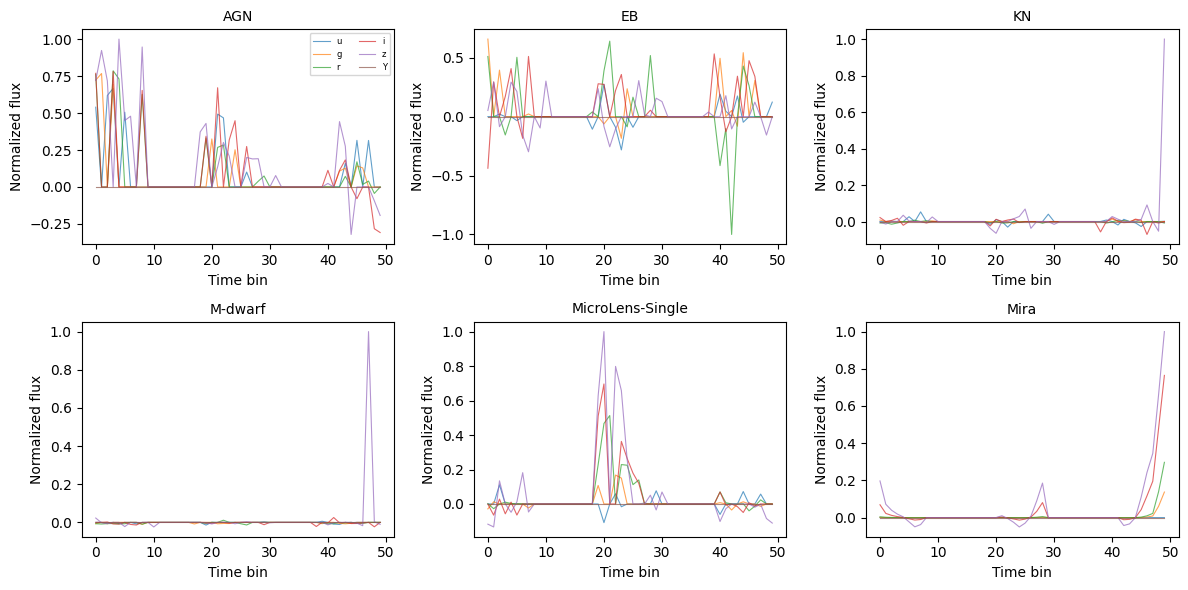

In [4]:
import matplotlib.pyplot as plt

show_classes = list(range(min(6, len(idx_to_name))))
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for ax, cls in zip(axes.flat, show_classes):
    sample_idx = np.where(labels == cls)[0][0]
    lc = lightcurves[sample_idx]
    for b in range(NUM_BANDS):
        ax.plot(lc[b], label=BAND_NAMES[b], alpha=0.7, linewidth=0.8)
    ax.set_title(idx_to_name[cls], fontsize=10)
    ax.set_xlabel("Time bin")
    ax.set_ylabel("Normalized flux")

axes[0, 0].legend(fontsize=6, ncol=2)
plt.tight_layout()
plt.show()

## Define a custom dataset

To use preprocessed data with Hyrax we subclass `HyraxDataset`.
A dataset needs to implement:
- `__len__` — the number of samples
- `get_<field>(idx)` methods for each field the model will consume

Any class that subclasses `HyraxDataset` is automatically registered and can be
referenced by name in a `data_request`.

In [5]:
from hyrax.datasets import HyraxDataset


class PLAsTiCCDataset(HyraxDataset):
    """Hyrax dataset for preprocessed PLAsTiCC light curves."""

    def __init__(self, config: dict, data_location=None):
        data_dir = Path(data_location)

        # Pick train or test split based on config
        ds_config = config.get("data_set", {}).get("PLAsTiCCDataset", {})
        split = "train" if ds_config.get("use_training_data", True) else "test"

        data = np.load(data_dir / f"{split}.npz")
        self.lightcurves = data["lightcurves"]
        self.labels = data["labels"]
        self.object_ids = data["object_ids"]

        super().__init__(config)

    def get_lightcurve(self, idx):
        """Return the binned light curve for one object."""
        return self.lightcurves[idx]

    def get_label(self, idx):
        """Return the integer class label."""
        return int(self.labels[idx])

    def get_object_id(self, idx):
        """Return a unique string identifier."""
        return str(self.object_ids[idx])

    def __len__(self):
        return len(self.labels)

## Define a custom model

Hyrax's built-in models are image-based (2-D convolutions), so we need a model that
works with 1-D time series. Any `torch.nn.Module` decorated with `@hyrax_model` is
automatically registered.

A model must implement:
- `__init__(config, data_sample)` — build the network, using `data_sample` for sizing
- `forward(x)` — the forward pass
- `train_batch(batch)` — one training step (loss + backward + optimizer step)
- `infer_batch(batch)` — one inference step
- `prepare_inputs(data_dict)` — a static method that converts the collated data
  dictionary into the numpy arrays the model expects

In [6]:
import torch.nn as nn
import torch.nn.functional as F
from hyrax.models import hyrax_model


@hyrax_model
class LightCurveCNN(nn.Module):
    """A simple 1-D CNN for multi-band light-curve classification."""

    def __init__(self, config, data_sample=None):
        super().__init__()
        self.config = config

        if data_sample is None:
            raise ValueError("A `data_sample` is required for dynamic sizing.")

        # data_sample is a tuple (lightcurve_batch, label_batch)
        lc_sample = data_sample[0]  # shape: (batch, bands, time_bins)
        _, num_channels, seq_len = lc_sample.shape
        num_classes = config["model"]["LightCurveCNN"]["output_classes"]

        self.features = nn.Sequential(
            nn.Conv1d(num_channels, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x, _ = x  # unpack (data, labels)
        x = self.features(x)
        x = x.squeeze(-1)  # (batch, 64)
        return self.classifier(x)

    def train_batch(self, batch):
        _, labels = batch
        self.optimizer.zero_grad()
        outputs = self(batch)
        loss = self.criterion(outputs, labels)
        loss.backward()
        self.optimizer.step()
        return {"loss": loss.item()}

    def validate_batch(self, batch):
        _, labels = batch
        outputs = self(batch)
        loss = self.criterion(outputs, labels)
        return {"loss": loss.item()}

    def test_batch(self, batch):
        return self.validate_batch(batch)

    def infer_batch(self, batch):
        return self(batch)

    @staticmethod
    def prepare_inputs(data_dict):
        """Convert the collated data dictionary to numpy arrays."""
        import numpy as np

        data = data_dict["data"]
        lightcurve = np.asarray(data["lightcurve"], dtype=np.float32)
        label = np.asarray(data.get("label", []), dtype=np.int64)
        return (lightcurve, label)

## Initialize Hyrax and configure

From here the workflow is the same as any other Hyrax example: create a `Hyrax` instance,
point it at our custom model and dataset, and run verbs.

In [ ]:
from hyrax import Hyrax

h = Hyrax()

h.set_config("model.name", "LightCurveCNN")

# Create the config section for our custom model (built-in models have this
# in hyrax_default_config.toml, but custom models need it added at runtime).
h.config["model"]["LightCurveCNN"] = {"output_classes": len(idx_to_name)}

h.set_config("data_loader.batch_size", 64)
h.set_config("train.epochs", 15)

## Define the dataset and train

We configure the `data_request` to use our custom `PLAsTiCCDataset` and request
the `lightcurve` and `label` fields. Note how the field names match the `get_lightcurve`
and `get_label` methods we defined above.

In [ ]:
data_request_definition = {
    "train": {
        "data": {
            "dataset_class": "PLAsTiCCDataset",
            "data_location": "./data/plasticc",
            "fields": ["lightcurve", "label"],
            "primary_id_field": "object_id",
            "split_fraction": 1.0,
        },
    },
}

h.set_config("data_request", data_request_definition)

trained_model = h.train()

## Predict with the model

We now classify the held-out test light curves. Setting `use_training_data` to `False`
via `dataset_config` tells our dataset to load `test.npz` instead of `train.npz`.

For custom datasets the `dataset_config` dictionary must be nested under the dataset
class name so that Hyrax knows which config section to update.

In [ ]:
data_request_definition["infer"] = {
    "data": {
        "dataset_class": "PLAsTiCCDataset",
        "data_location": "./data/plasticc",
        "fields": ["lightcurve", "object_id"],
        "primary_id_field": "object_id",
        "dataset_config": {
            "PLAsTiCCDataset": {
                "use_training_data": False,
            },
        },
    },
}

h.set_config("data_request", data_request_definition)

inference_results = h.infer()

## Evaluate the performance

The model outputs a 14-element vector per light curve. The index of the maximum value
is the predicted class. We compare against the true labels and display a confusion matrix.

Accuracy: 40.19%


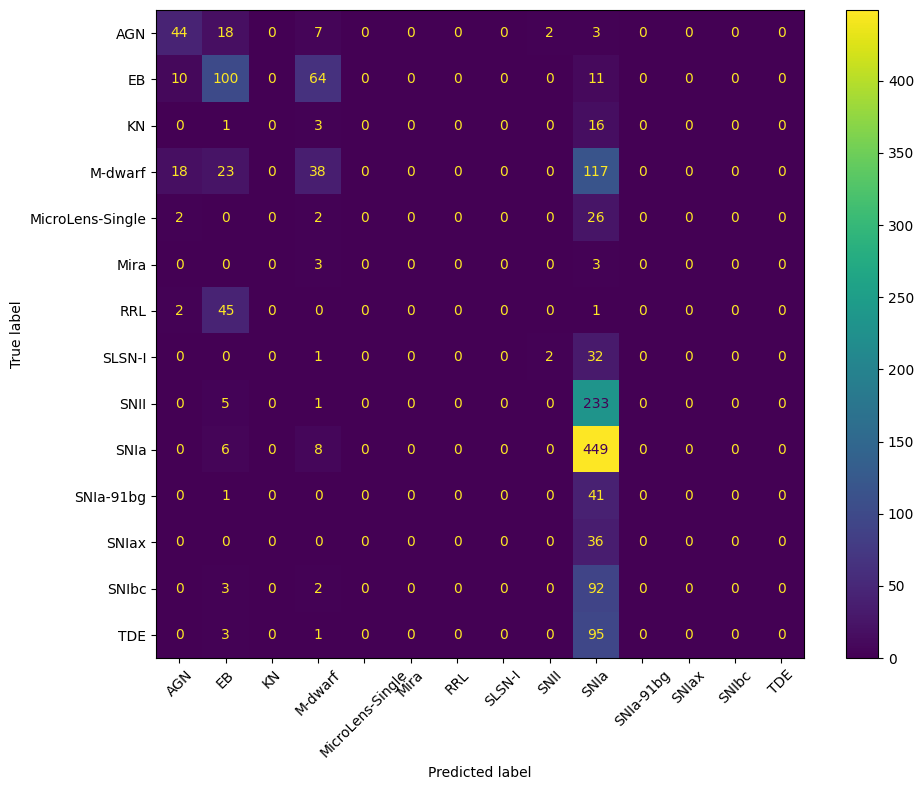

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Predicted classes
y_pred = [inference_results[i].argmax() for i in range(len(inference_results))]

# True labels from saved test split
test_data = np.load("./data/plasticc/test.npz")
y_true = test_data["labels"].tolist()

correct = sum(t == p for t, p in zip(y_true, y_pred))
print(f"Accuracy: {correct / len(y_true):.2%}")

class_names = [idx_to_name[i] for i in range(len(idx_to_name))]

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.tight_layout()
plt.show()

## What to take away

1. **Hyrax is not limited to images.** By defining a custom dataset and model, you can
   work with light curves, spectra, or any other data modality.
2. **Custom datasets** subclass `HyraxDataset` and provide `get_<field>()` methods.
   The field names you define here are the same ones you list in the `data_request`
   and extract in the model's `prepare_inputs`.
3. **Custom models** are standard `torch.nn.Module` classes decorated with `@hyrax_model`.
   Implement `train_batch`, `infer_batch`, and `prepare_inputs`, and Hyrax handles the rest.
4. **The core Hyrax workflow is the same** regardless of data type: configure → train → infer → evaluate.